# 📚 Guide du Dataset FEVER

## Qu'est-ce que FEVER ?

```FEVER (Fact Extraction and VERification)```, créé en 2018 par des chercheurs de l'Université de Cambridge, est un dataset conçu pour la vérification automatique des faits.

### 🎯 Objectif

L'objetif est de développer des systèmes capables de :

Extraire des informations pertinentes depuis Wikipedia

Vérifier si une affirmation est vraie ou fausse

Justifier la décision avec des preuves

In [43]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import requests
from datasets import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder


def load_fever_batch():
    """Charge FEVER depuis l'URL officielle"""
    url = "https://fever.ai/download/fever/train.jsonl"
    response = requests.get(url)
    response.raise_for_status()
    
    batch = []
    for line in response.text.strip().split('\n'):
        if line:
            item = json.loads(line)
            batch.append({
                'id': str(item.get('id', '')),
                'claim': item.get('claim', ''),
                'label': item.get('label', '')
            })
    
    return Dataset.from_list(batch)

# Charger les données
data = load_fever_batch()
print(f"📊 Dataset chargé: {len(data)} exemples")

📊 Dataset chargé: 145449 exemples



### Entrées et sorties

In [44]:
print("Premiers exemples:")
for i in range(5):
    print(f"Exemple {i}: {data[i]}")

Premiers exemples:
Exemple 0: {'id': '75397', 'claim': 'Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.', 'label': 'SUPPORTS'}
Exemple 1: {'id': '150448', 'claim': 'Roman Atwood is a content creator.', 'label': 'SUPPORTS'}
Exemple 2: {'id': '214861', 'claim': 'History of art includes architecture, dance, sculpture, music, painting, poetry literature, theatre, narrative, film, photography and graphic arts.', 'label': 'SUPPORTS'}
Exemple 3: {'id': '156709', 'claim': 'Adrienne Bailon is an accountant.', 'label': 'REFUTES'}
Exemple 4: {'id': '83235', 'claim': 'System of a Down briefly disbanded in limbo.', 'label': 'NOT ENOUGH INFO'}



Input  : Une affirmation (claim)

Output : Label (SUPPORTS, REFUTES, NOT ENOUGH INFO) 

### 🌟 Pourquoi FEVER est important ?

Lutte contre la désinformation : Identifier les fausses nouvelles

Recherche en NLP : Combinaison de compréhension du langage et de raisonnement

Benchmark : Référence standard pour les systèmes de vérification

Transparence : Nécessite des preuves, pas juste une classification

## Structure du Dataset

### 📊 Format des Données
Chaque exemple dans FEVER est un objet JSON avec les champs suivants :

In [45]:
data

Dataset({
    features: ['id', 'claim', 'label'],
    num_rows: 145449
})

### 📋 Description des Champs


| Champ| Type | Description | Exemple |
|:--------------------|:------:|-------:|-------:|
| `id`     | int/string | Identifiant unique du claim | 12345  |
| `Claim`       | string   | L'affirmation à vérifier    |  "Nikolaj Coster-Waldau was born in Denmark"  |
| `label`       | Test   | 123    | "SUPPORTS" |

## Les Labels

### Les 3 Classes Principales
		

| Label | Signification | Exemple |
|----------------|--------|----------|
| ✅ SUPPORTS | L'affirmation est vraie | "Paris est la capitale de la France" → VRAI" |
|  REFUTES | L'affirmation est fausse | "La capitale de la France est Berlin" → FAUX |
| NOT ENOUGH INFO	| Pas assez d'informations pour vérifier | "Le président de la France en 2050 sera..." → INCONNU |

### 📊 Distribution des 145,449 exemples :

In [50]:
# Distribution des labels
labels = data['label']
label_counts = Counter(labels)
print("\n")
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(data)*100:.1f}%)")



  SUPPORTS: 80035 (55.0%)
  REFUTES: 29775 (20.5%)
  NOT ENOUGH INFO: 35639 (24.5%)


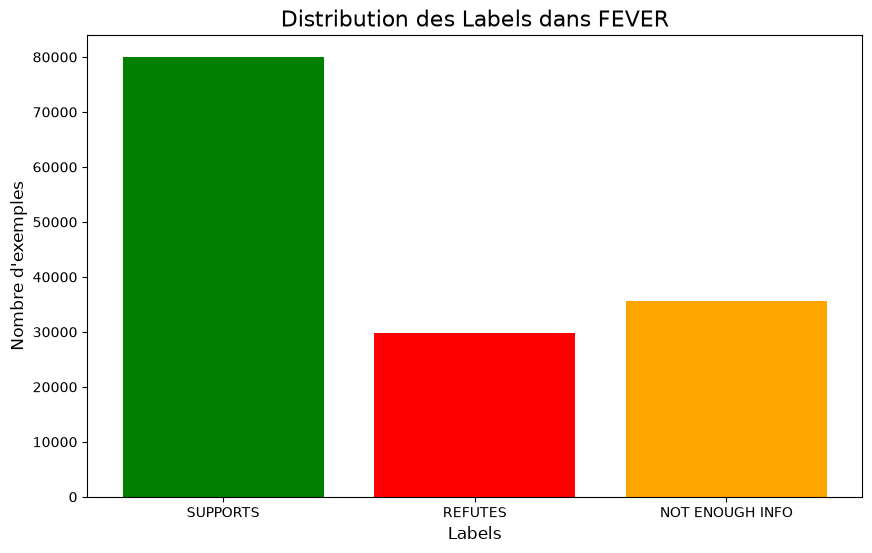

In [51]:
from collections import Counter

# Distribution des labels

plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'orange']
plt.bar(label_counts.keys(), label_counts.values(), color=colors)
plt.title('Distribution des Labels dans FEVER', fontsize=16)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Nombre d\'exemples', fontsize=12)
plt.show()

## Taille et Statistiques
### 📊 Vue d'Ensemble



In [34]:

def load_all_splits():
    """Charge tous les splits de FEVER"""
    splits = {
        "train": "https://fever.ai/download/fever/train.jsonl",
        "validation": "https://fever.ai/download/fever/shared_task_dev.jsonl",
        "test": "https://fever.ai/download/fever/shared_task_test.jsonl"
    }
    
    datasets = {}
    
    for name, url in splits.items():
        print(f"📥 Chargement de {name}...")
        response = requests.get(url)
        response.raise_for_status()
        
        data = []
        for line in response.text.strip().split('\n'):
            if line:
                item = json.loads(line)
                data.append({
                    'id': str(item.get('id', '')),
                    'claim': item.get('claim', ''),
                    'label': item.get('label', '')
                })
        
        datasets[name] = Dataset.from_list(data)
        print(f"✅ {name}: {len(data)} exemples")
    
    return datasets

# Charger tous les splits
all_splits = load_all_splits()
train_data = all_splits["train"]
validation_data = all_splits["validation"]
test_data = all_splits["test"]

print(f"\nLes données sont au nombre de: {len(train_data) + len(validation_data) +len(test_data)} et reparties en : ")
print(f"\nTrain: {len(train_data)}")
print(f"Validation: {len(validation_data)}")
print(f"Test: {len(test_data)}")


📥 Chargement de train...
✅ train: 145449 exemples
📥 Chargement de validation...
✅ validation: 19998 exemples
📥 Chargement de test...
✅ test: 19998 exemples

Les données sont au nombre de: 185445 et reparties en : 

Train: 145449
Validation: 19998
Test: 19998


| Split	| Exemples | Source |
|:--------------------|:------:|-------:|
| Train	| 145,449 | fever.ai/download/fever/train.jsonl |
| Validation | 19,998 | fever.ai/download/fever/shared_task_dev.jsonl |
| Test | 19,998 | fever.ai/download/fever/shared_task_test.jsonl |

### Longueur des mots

In [22]:
# Longueur des claims
claim_lengths = [len(claim.split()) for claim in data['claim']]
print("\n📝 Longueur des claims:")
print(f"  Moyenne : {np.mean(claim_lengths):.1f} mots")
print(f"  Min     : {np.min(claim_lengths)} mots")
print(f"  Max     : {np.max(claim_lengths)} mots")


📝 Longueur des claims:
  Moyenne : 8.1 mots
  Min     : 2 mots
  Max     : 65 mots


## 🧹 Prétraitement

In [52]:
def preprocess_fever(train_data, val_data=None):
    """Prépare FEVER pour l'entraînement"""
    
    def clean_claim(claim):
        claim = claim.lower()
        claim = re.sub(r'[^\w\s]', '', claim)
        return claim
    
    # Filtrer les labels valides
    valid_labels = ['SUPPORTS', 'REFUTES', 'NOT ENOUGH INFO']
    train_filtered = train_data.filter(lambda x: x['label'] in valid_labels)
    
    # Extraire et nettoyer les claims
    X_train = [clean_claim(c) for c in train_filtered['claim']]
    
    # Encoder les labels
    le = LabelEncoder()
    y_train = le.fit_transform(train_filtered['label'])
    
    if val_data is not None:
        val_filtered = val_data.filter(lambda x: x['label'] in valid_labels)
        X_val = [clean_claim(c) for c in val_filtered['claim']]
        y_val = le.transform(val_filtered['label'])
        return X_train, y_train, X_val, y_val, le
    else:
        return X_train, y_train, le

## Vectorization et evaluation du model Logistic Regression

In [53]:
def train_and_evaluate(X_train, y_train, X_val, y_val, le):
    """Entraîne et évalue un classifieur"""
    
    # Vectorisation
    vectorizer = TfidfVectorizer(
        max_features=10000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    
    # Entraînement
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_vec, y_train)
    
    # Évaluation
    y_pred = clf.predict(X_val_vec)
    
    print("\n📊 Rapport de classification:")
    print(classification_report(y_val, y_pred, target_names=le.classes_))
    
    # Précision
    accuracy = (y_pred == y_val).mean()
    print(f"\n✅ Précision: {accuracy:.2%}")
    
    return clf, vectorizer

In [54]:
X_train, y_train, X_val, y_val, le = preprocess_fever(train_data, validation_data)
print(f"\n📊 Train: {len(X_train)} exemples")
print(f"📊 Validation: {len(X_val)} exemples")
print(f"🏷️ Classes: {le.classes_}")

# Entraîner et évaluer
clf, vectorizer = train_and_evaluate(X_train, y_train, X_val, y_val, le)

Filter: 100%|██████████| 19998/19998 [00:00<00:00, 762725.55 examples/s]



📊 Train: 145449 exemples
📊 Validation: 19998 exemples
🏷️ Classes: ['NOT ENOUGH INFO' 'REFUTES' 'SUPPORTS']

📊 Rapport de classification:
                 precision    recall  f1-score   support

NOT ENOUGH INFO       0.49      0.20      0.29      6666
        REFUTES       0.67      0.27      0.38      6666
       SUPPORTS       0.39      0.86      0.54      6666

       accuracy                           0.44     19998
      macro avg       0.52      0.44      0.40     19998
   weighted avg       0.52      0.44      0.40     19998


✅ Précision: 44.19%
